In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import os

print(os.listdir("/kaggle/input"))

[]


In [5]:
DATASET_PATH = "/kaggle/input/betel-leaf-dataset-split"

print(os.listdir(DATASET_PATH))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/betel-leaf-dataset-split'

In [6]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [7]:
import os

print(os.listdir("/kaggle/input/datasets"))

['efrathhossainshihab']


In [8]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    print("Folders:", dirs)
    print("Files:", files[:5])
    print("-" * 50)

/kaggle/input
Folders: ['datasets']
Files: []
--------------------------------------------------
/kaggle/input/datasets
Folders: ['efrathhossainshihab']
Files: []
--------------------------------------------------
/kaggle/input/datasets/efrathhossainshihab
Folders: ['betel-leaf-dataset-split']
Files: []
--------------------------------------------------
/kaggle/input/datasets/efrathhossainshihab/betel-leaf-dataset-split
Folders: ['Betel_Leaf_DataSet_Split']
Files: []
--------------------------------------------------
/kaggle/input/datasets/efrathhossainshihab/betel-leaf-dataset-split/Betel_Leaf_DataSet_Split
Folders: ['validation', 'train_augmented_1100', 'test', 'Train']
Files: []
--------------------------------------------------
/kaggle/input/datasets/efrathhossainshihab/betel-leaf-dataset-split/Betel_Leaf_DataSet_Split/validation
Folders: ['Leaf_Rot', 'Leaf_Curl', 'Anthracnose', 'Leaf_Spot', 'Healthy']
Files: []
--------------------------------------------------
/kaggle/input/datas

In [9]:
/kaggle/input/datasets/betel-leaf-dataset-split

NameError: name 'kaggle' is not defined

In [10]:
DATASET_PATH = "/kaggle/input/datasets/betel-leaf-dataset-split"

print(os.listdir(DATASET_PATH))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/betel-leaf-dataset-split'

In [12]:
DATASET_PATH = "/kaggle/input/datasets/efrathhossainshihab/betel-leaf-dataset-split/Betel_Leaf_DataSet_Split"

In [13]:
import os

DATASET_PATH = "/kaggle/input/datasets/efrathhossainshihab/betel-leaf-dataset-split/Betel_Leaf_DataSet_Split"

print(os.listdir(DATASET_PATH))

['validation', 'train_augmented_1100', 'test', 'Train']


In [16]:
TRAIN_DIR = DATASET_PATH + "/train_augmented_1100"
VAL_DIR   = DATASET_PATH + "/validation"
TEST_DIR  = DATASET_PATH + "/test"

In [17]:
import os

TRAIN_DIR = DATASET_PATH + "/train_augmented_1100"
VAL_DIR   = DATASET_PATH + "/validation"
TEST_DIR  = DATASET_PATH + "/test"

for name, path in [
    ("TRAIN", TRAIN_DIR),
    ("VALIDATION", VAL_DIR),
    ("TEST", TEST_DIR)
]:
    print(f"\n{name}")
    print("-" * 40)

    for class_name in sorted(os.listdir(path)):
        class_path = os.path.join(path, class_name)

        if os.path.isdir(class_path):
            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]

            print(f"{class_name}: {len(images)}")


TRAIN
----------------------------------------
Anthracnose: 1100
Healthy: 1100
Leaf_Curl: 1100
Leaf_Rot: 1100
Leaf_Spot: 1100

VALIDATION
----------------------------------------
Anthracnose: 137
Healthy: 137
Leaf_Curl: 137
Leaf_Rot: 137
Leaf_Spot: 137

TEST
----------------------------------------
Anthracnose: 137
Healthy: 137
Leaf_Curl: 137
Leaf_Rot: 137
Leaf_Spot: 137


In [19]:
import tensorflow as tf

print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: []


2026-08-27 21:07:43.617332: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [1]:
!nvidia-smi

Thu Aug 27 21:10:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')
print(mixed_precision.global_policy())

<DTypePolicy "mixed_float16">


In [6]:
import os

DATASET_PATH = "/kaggle/input/datasets/efrathhossainshihab/betel-leaf-dataset-split/Betel_Leaf_DataSet_Split"

TRAIN_DIR = os.path.join(DATASET_PATH, "train_augmented_1100")
VAL_DIR   = os.path.join(DATASET_PATH, "validation")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 5500 files belonging to 5 classes.


I0000 00:00:1787865121.390231      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787865121.393173      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 685 files belonging to 5 classes.
Found 685 files belonging to 5 classes.


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [10]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras import mixed_precision

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# Faster training on T4 GPU
mixed_precision.set_global_policy("mixed_float16")

print("Mixed Precision Policy:", mixed_precision.global_policy())

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed Precision Policy: <DTypePolicy "mixed_float16">


In [11]:
DATASET_PATH = "/kaggle/input/datasets/efrathhossainshihab/betel-leaf-dataset-split/Betel_Leaf_DataSet_Split"

TRAIN_DIR = os.path.join(DATASET_PATH, "train_augmented_1100")
VAL_DIR   = os.path.join(DATASET_PATH, "validation")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: /kaggle/input/datasets/efrathhossainshihab/betel-leaf-dataset-split/Betel_Leaf_DataSet_Split/train_augmented_1100
Validation: /kaggle/input/datasets/efrathhossainshihab/betel-leaf-dataset-split/Betel_Leaf_DataSet_Split/validation
Test: /kaggle/input/datasets/efrathhossainshihab/betel-leaf-dataset-split/Betel_Leaf_DataSet_Split/test


In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
NUM_CLASSES = 5

In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 5500 files belonging to 5 classes.
Found 685 files belonging to 5 classes.
Found 685 files belonging to 5 classes.


In [14]:
class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of Classes:", len(class_names))

Classes: ['Anthracnose', 'Healthy', 'Leaf_Curl', 'Leaf_Rot', 'Leaf_Spot']
Number of Classes: 5


In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

In [17]:
base_model = ResNet50V2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Stage 1: freeze pretrained ResNet50V2
base_model.trainable = False

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
inputs = layers.Input(shape=(224, 224, 3))

# ResNet50V2 preprocessing
x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32"
)(x)

model = Model(inputs, outputs)

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,090,629 (91.90 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [20]:
checkpoint_path = "/kaggle/working/best_resnet50v2.keras"

callbacks_stage1 = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [21]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_stage1
)

Epoch 1/10
  5/172 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.2427 - loss: 2.1729 

I0000 00:00:1787865405.329879     152 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.6259 - loss: 0.9994
Epoch 1: val_accuracy improved from None to 0.87591, saving model to /kaggle/working/best_resnet50v2.keras

Epoch 1: finished saving model to /kaggle/working/best_resnet50v2.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 127s 630ms/step - accuracy: 0.7311 - loss: 0.7065 - val_accuracy: 0.8759 - val_loss: 0.3225 - learning_rate: 0.0010
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.8570 - loss: 0.3882
Epoch 2: val_accuracy improved from 0.87591 to 0.90073, saving model to /kaggle/working/best_resnet50v2.keras

Epoch 2: finished saving model to /kaggle/working/best_resnet50v2.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 76s 444ms/step - accuracy: 0.8484 - loss: 0.3997 - val_accuracy: 0.9007 - val_loss: 0.2743 - learning_rate: 0.0010
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.8842 - loss: 0.3128
Epoch 3: val_accuracy improved from 0.90073 to 0.91679, saving model to /kaggle/working/best_re

In [22]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/kaggle/working/best_resnet50v2.keras"
)

print("Best Stage 1 model loaded!")

Best Stage 1 model loaded!


In [23]:
base_model = model.get_layer("resnet50v2")

base_model.trainable = True

# প্রথম সব layer freeze
for layer in base_model.layers:
    layer.trainable = False

# শুধু শেষ 30 layer trainable
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Batch Normalization layers frozen রাখবো
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total base layers:", len(base_model.layers))
print(
    "Trainable base layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Total base layers: 190
Trainable base layers: 22


In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

FINE_TUNE_PATH = "/kaggle/working/best_resnet50v2_finetuned.keras"

callbacks_stage2 = [
    ModelCheckpoint(
        FINE_TUNE_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [27]:
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=10,
    epochs=20,
    callbacks=callbacks_stage2
)

Epoch 11/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9507 - loss: 0.1322
Epoch 11: val_accuracy improved from None to 0.95036, saving model to /kaggle/working/best_resnet50v2_finetuned.keras

Epoch 11: finished saving model to /kaggle/working/best_resnet50v2_finetuned.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 107s 520ms/step - accuracy: 0.9558 - loss: 0.1219 - val_accuracy: 0.9504 - val_loss: 0.1427 - learning_rate: 1.0000e-05
Epoch 12/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9794 - loss: 0.0678
Epoch 12: val_accuracy improved from 0.95036 to 0.96204, saving model to /kaggle/working/best_resnet50v2_finetuned.keras

Epoch 12: finished saving model to /kaggle/working/best_resnet50v2_finetuned.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 77s 449ms/step - accuracy: 0.9805 - loss: 0.0603 - val_accuracy: 0.9620 - val_loss: 0.1210 - learning_rate: 1.0000e-05
Epoch 13/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9893 - loss: 0.0355
Epoch 13: val_accuracy did no

In [28]:
best_model = tf.keras.models.load_model(
    "/kaggle/working/best_resnet50v2_finetuned.keras"
)

In [29]:
test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 512ms/step - accuracy: 0.9533 - loss: 0.2139
Test Loss     : 0.2139
Test Accuracy : 95.33%


In [30]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [31]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

 Anthracnose     0.9632    0.9562    0.9597       137
     Healthy     0.9927    0.9927    0.9927       137
   Leaf_Curl     0.9856    1.0000    0.9928       137
    Leaf_Rot     0.9014    0.9343    0.9176       137
   Leaf_Spot     0.9237    0.8832    0.9030       137

    accuracy                         0.9533       685
   macro avg     0.9533    0.9533    0.9531       685
weighted avg     0.9533    0.9533    0.9531       685



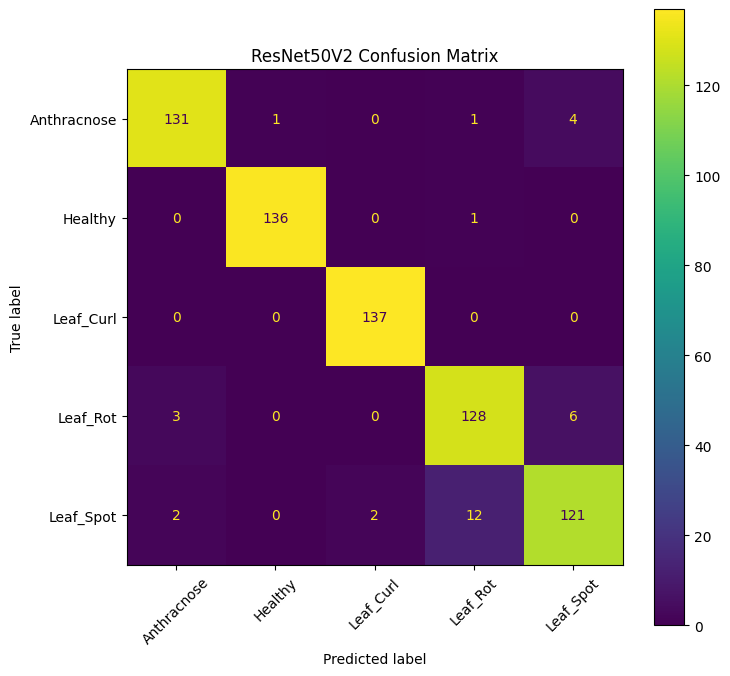

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("ResNet50V2 Confusion Matrix")
plt.show()

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-score  : {f1 * 100:.2f}%")

Accuracy  : 95.33%
Precision : 95.33%
Recall    : 95.33%
F1-score  : 95.31%


In [34]:
import numpy as np
import tensorflow as tf

y_true = []
y_prob = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)

    y_prob.extend(probs)
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_pred = np.argmax(y_prob, axis=1)

print("Predictions generated successfully!")
print("Test samples:", len(y_true))

Predictions generated successfully!
Test samples: 685


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_true, y_pred)

precision_macro = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall_macro = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro"
)

precision_weighted = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall_weighted = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy            : {accuracy * 100:.2f}%")
print(f"Macro Precision     : {precision_macro * 100:.2f}%")
print(f"Macro Recall        : {recall_macro * 100:.2f}%")
print(f"Macro F1 Score      : {f1_macro * 100:.2f}%")
print()
print(f"Weighted Precision  : {precision_weighted * 100:.2f}%")
print(f"Weighted Recall     : {recall_weighted * 100:.2f}%")
print(f"Weighted F1 Score   : {f1_weighted * 100:.2f}%")

Accuracy            : 95.33%
Macro Precision     : 95.33%
Macro Recall        : 95.33%
Macro F1 Score      : 95.31%

Weighted Precision  : 95.33%
Weighted Recall     : 95.33%
Weighted F1 Score   : 95.31%


In [36]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

 Anthracnose     0.9632    0.9562    0.9597       137
     Healthy     0.9927    0.9927    0.9927       137
   Leaf_Curl     0.9856    1.0000    0.9928       137
    Leaf_Rot     0.9014    0.9343    0.9176       137
   Leaf_Spot     0.9237    0.8832    0.9030       137

    accuracy                         0.9533       685
   macro avg     0.9533    0.9533    0.9531       685
weighted avg     0.9533    0.9533    0.9531       685



In [37]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

num_classes = len(class_names)

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(num_classes)
)

macro_auc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

weighted_auc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="weighted",
    multi_class="ovr"
)

print(f"Macro ROC-AUC    : {macro_auc:.4f}")
print(f"Weighted ROC-AUC : {weighted_auc:.4f}")

Macro ROC-AUC    : 0.9948
Weighted ROC-AUC : 0.9948


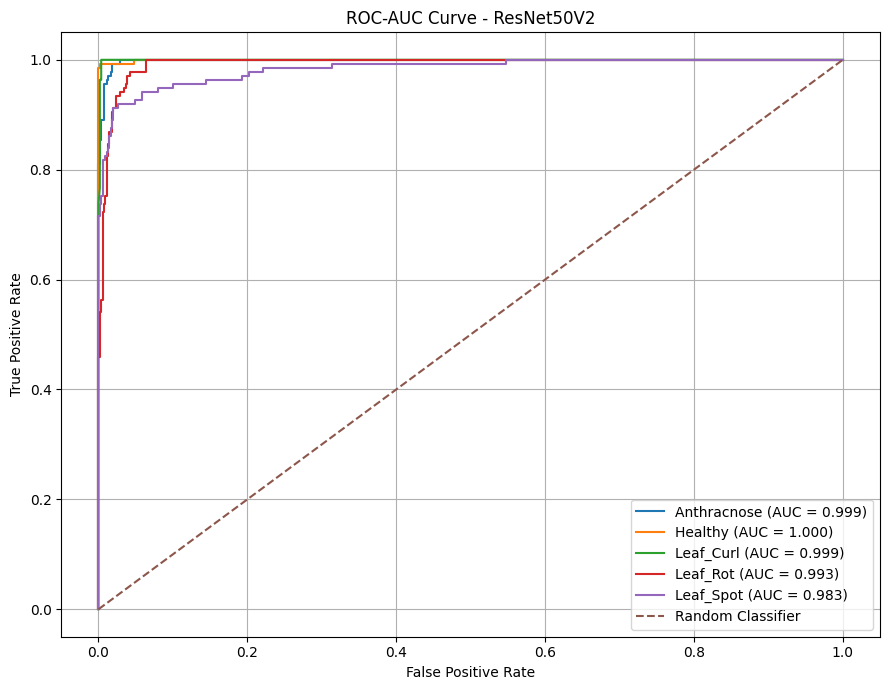

In [38]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 7))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve - ResNet50V2")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet50v2_roc_auc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
train_accuracy = (
    history_stage1.history["accuracy"]
    + history_stage2.history["accuracy"]
)

val_accuracy = (
    history_stage1.history["val_accuracy"]
    + history_stage2.history["val_accuracy"]
)

epochs_range = range(
    1,
    len(train_accuracy) + 1
)

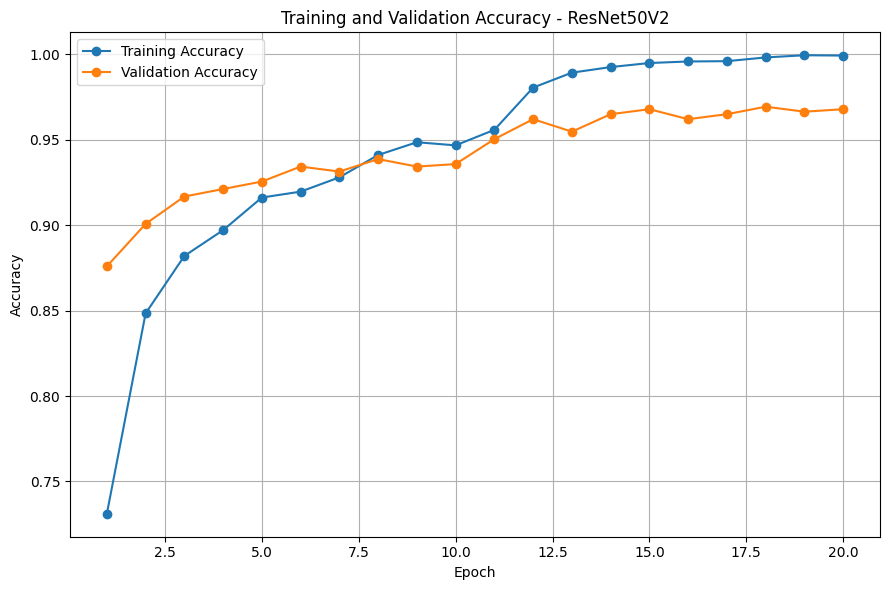

In [40]:
plt.figure(figsize=(9, 6))

plt.plot(
    epochs_range,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy - ResNet50V2")

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet50v2_validation_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

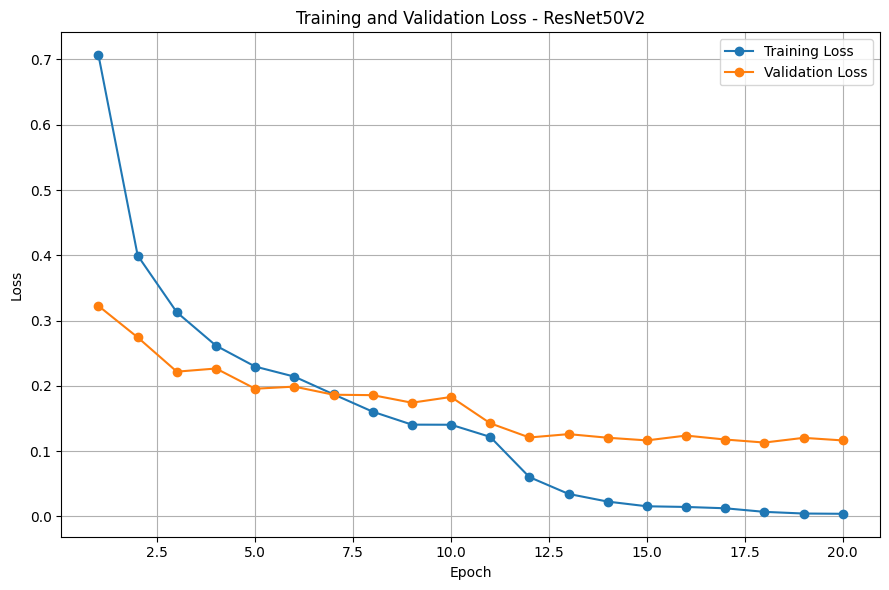

In [41]:
train_loss = (
    history_stage1.history["loss"]
    + history_stage2.history["loss"]
)

val_loss = (
    history_stage1.history["val_loss"]
    + history_stage2.history["val_loss"]
)

epochs_range_loss = range(
    1,
    len(train_loss) + 1
)

plt.figure(figsize=(9, 6))

plt.plot(
    epochs_range_loss,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range_loss,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss - ResNet50V2")

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet50v2_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
print("=" * 55)
print("        ResNet50V2 FINAL TEST RESULTS")
print("=" * 55)

print(f"Accuracy             : {accuracy * 100:.2f}%")
print(f"Precision (Macro)    : {precision_macro * 100:.2f}%")
print(f"Recall (Macro)       : {recall_macro * 100:.2f}%")
print(f"F1 Score (Macro)     : {f1_macro * 100:.2f}%")
print(f"ROC-AUC (Macro)      : {macro_auc:.4f}")

print("-" * 55)

print(f"Precision (Weighted) : {precision_weighted * 100:.2f}%")
print(f"Recall (Weighted)    : {recall_weighted * 100:.2f}%")
print(f"F1 Score (Weighted)  : {f1_weighted * 100:.2f}%")
print(f"ROC-AUC (Weighted)   : {weighted_auc:.4f}")

print("-" * 55)

print("R²                   : N/A (Regression Metric)")
print("RMSE                 : N/A (Regression Metric)")

print("=" * 55)

        ResNet50V2 FINAL TEST RESULTS
Accuracy             : 95.33%
Precision (Macro)    : 95.33%
Recall (Macro)       : 95.33%
F1 Score (Macro)     : 95.31%
ROC-AUC (Macro)      : 0.9948
-------------------------------------------------------
Precision (Weighted) : 95.33%
Recall (Weighted)    : 95.33%
F1 Score (Weighted)  : 95.31%
ROC-AUC (Weighted)   : 0.9948
-------------------------------------------------------
R²                   : N/A (Regression Metric)
RMSE                 : N/A (Regression Metric)


In [43]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Done!")
print("Total test samples:", len(y_true))

Done!
Total test samples: 685


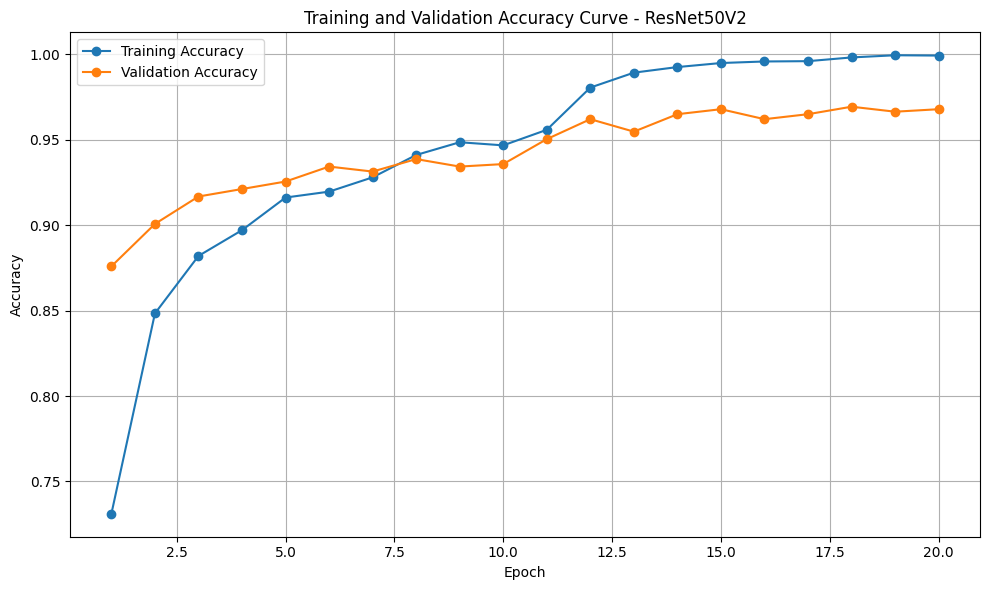

In [44]:
import matplotlib.pyplot as plt

# Stage 1 + Stage 2 history combine
train_accuracy = history_stage1.history["accuracy"] + history_stage2.history["accuracy"]
val_accuracy = history_stage1.history["val_accuracy"] + history_stage2.history["val_accuracy"]

epochs_acc = range(1, len(train_accuracy) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_acc, train_accuracy, marker='o', label='Training Accuracy')
plt.plot(epochs_acc, val_accuracy, marker='o', label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Curve - ResNet50V2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("/kaggle/working/resnet50v2_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

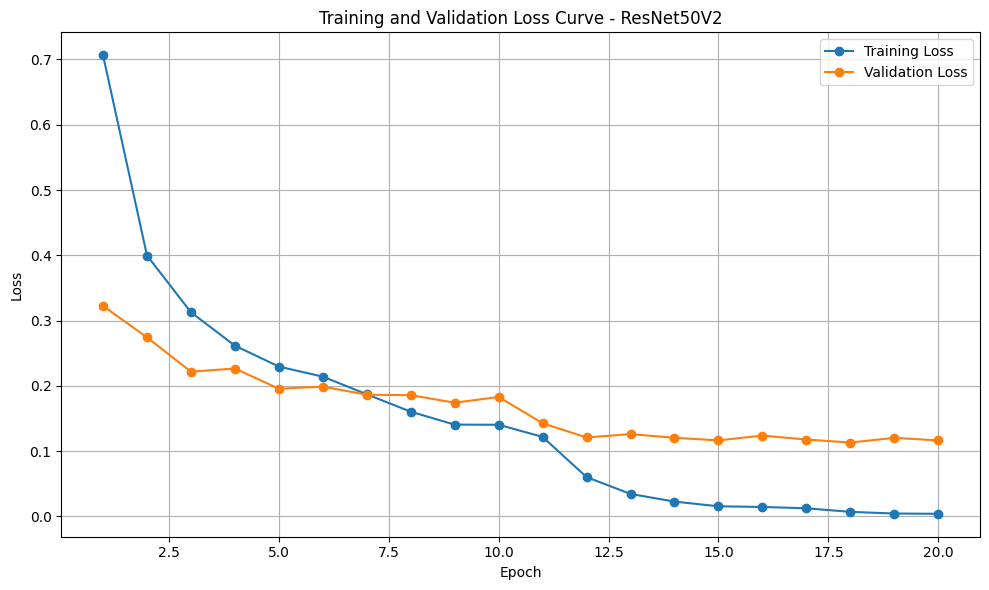

In [45]:
train_loss = history_stage1.history["loss"] + history_stage2.history["loss"]
val_loss = history_stage1.history["val_loss"] + history_stage2.history["val_loss"]

epochs_loss = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_loss, train_loss, marker='o', label='Training Loss')
plt.plot(epochs_loss, val_loss, marker='o', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve - ResNet50V2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("/kaggle/working/resnet50v2_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

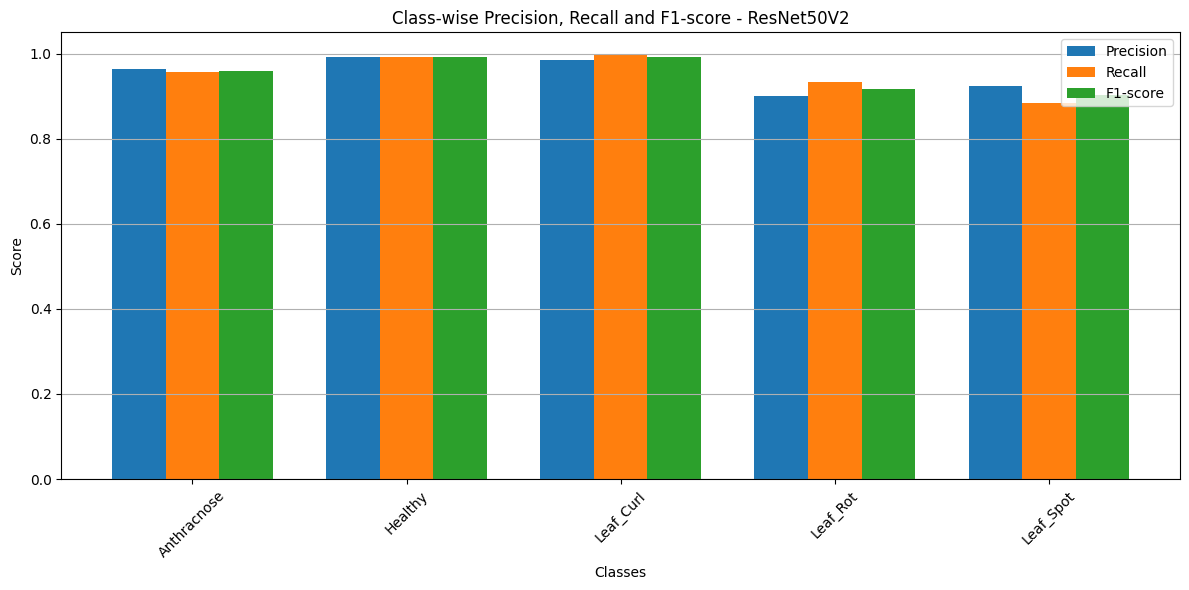

In [46]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    average=None
)

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xlabel("Classes")
plt.ylabel("Score")
plt.title("Class-wise Precision, Recall and F1-score - ResNet50V2")
plt.xticks(x, class_names, rotation=45)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()

plt.savefig("/kaggle/working/resnet50v2_classwise_prf_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
for i, class_name in enumerate(class_names):
    print(f"{class_name}")
    print(f"  Precision : {precision[i]:.4f}")
    print(f"  Recall    : {recall[i]:.4f}")
    print(f"  F1-score  : {f1[i]:.4f}")
    print(f"  Support   : {support[i]}")
    print()

Anthracnose
  Precision : 0.9632
  Recall    : 0.9562
  F1-score  : 0.9597
  Support   : 137

Healthy
  Precision : 0.9927
  Recall    : 0.9927
  F1-score  : 0.9927
  Support   : 137

Leaf_Curl
  Precision : 0.9856
  Recall    : 1.0000
  F1-score  : 0.9928
  Support   : 137

Leaf_Rot
  Precision : 0.9014
  Recall    : 0.9343
  F1-score  : 0.9176
  Support   : 137

Leaf_Spot
  Precision : 0.9237
  Recall    : 0.8832
  F1-score  : 0.9030
  Support   : 137



In [48]:
import os
import zipfile

# কোন folder থেকে PNG file collect করবে
source_folder = "/kaggle/working"

# zip file name
zip_path = "/kaggle/working/all_png_files.zip"

# zip তৈরি
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(source_folder):
        for file in files:
            if file.lower().endswith(".png"):
                file_path = os.path.join(root, file)
                
                # zip এর ভিতরে file name ঠিক রাখতে
                arcname = os.path.relpath(file_path, source_folder)
                zipf.write(file_path, arcname)

print("ZIP file created successfully!")
print("Saved at:", zip_path)

ZIP file created successfully!
Saved at: /kaggle/working/all_png_files.zip


In [49]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if file.lower().endswith(".png"):
            print(os.path.join(root, file))

/kaggle/working/resnet50v2_classwise_prf_bar_chart.png
/kaggle/working/resnet50v2_roc_auc_curve.png
/kaggle/working/resnet50v2_validation_accuracy_curve.png
/kaggle/working/resnet50v2_accuracy_curve.png
/kaggle/working/resnet50v2_loss_curve.png
